[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Evaluation

**Purpose.** Show a network engineer what each optimization method would change on
the network, against the deployed configuration, with enough evidence to verify
the numbers, compare the methods and decide what to apply.

**Inputs.** The newest run of each method under `outputs/optim/`, the incumbent
radio map `data/interim/radio_map.npz` (RSRP and the solver's SINR), and
`data/processed/mdt.parquet` and `cell.parquet`.

**Outputs.** Tables in `reports/tables/04_evaluation/`, figures in
`reports/figures/04_evaluation/`.

| Section | Question it answers |
|---|---|
| 3 | What did each method score, and are those scores reproducible from the maps? |
| 4 | How did RSRP and SINR change, and where? |
| 5 | Which tiles crossed the hole / weak thresholds, by area and by demand? |
| 6 | Did co-band overlap (interference) grow or shrink? |
| 7 | How does PRB demand, cell-band load, UE service and band steering move? |
| 8 | Which cells gain or shed traffic, and at what load? |
| 9 | How far do the antennas move? |
| 10 | How did the searches themselves behave? |

### This notebook needs no GPU

Nothing here re-solves. Every configuration is read from the radio map its run
archived, and the serving rule, PRB demand and KPIs are recomputed from those
maps on the CPU with the same functions the optimizer scored with.

### Demand-weighted numbers are diagnostics, not objectives

Views weighted by PRB demand are reporting views. No optimizer has seen them, and
they cut the map at the same `cfg.kpi` thresholds the four KPIs of
[ADR 0001](../docs/adr/0001-five-kpis-under-lexicographic-priority.md) do.

## 0. Environment

Run this section first, wherever you are.

**Locally** it walks up to the project root and makes it the working directory,
so the root-relative paths in the configs resolve the way they do for
`task bo` and the DVC pipeline. Nothing is installed.

**In Colab** it also clones the repository, puts it on `sys.path`, and installs
what Colab does not ship. No GPU runtime is needed here - but `outputs/` and
`data/` are not in the clone, so mount Drive below or there will be nothing to
evaluate.


In [1]:
# --- Environment bootstrap -------------------------------------------------
# Identical in every notebook in this project.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
BRANCH = "main"
SUBDIR = ""  # the project root is the repository root

# (import name, pip name). No sionna-rt: this notebook reads artifacts and
# never solves, so it runs on a CPU runtime.
COLAB_PACKAGES = [
    ("hydra", "hydra-core"),
]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    checkout = Path("/content") / Path(REPO_URL).stem
    if not checkout.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],
            check=True,
        )
    root = checkout / SUBDIR if SUBDIR else checkout
    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    # JupyterLab starts the kernel in notebooks/; walk up to the project root.
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))  # makes `import src` work without an editable install

# Extra Hydra overrides consumed by load_config() in section 1. Empty unless
# the Drive cell below fills it in, so local runs are unaffected.
CONFIG_OVERRIDES: list[str] = []

print(f"project root: {root}   colab: {IN_COLAB}")

project root: d:\Projects\band-tilt   colab: False


In [2]:
# --- Colab: data and artifacts (optional) ----------------------------------
# data/ is DVC-tracked and not part of the clone, so a fresh Colab runtime has
# no scenario to optimize against. Either run notebook 00 first, or mount Drive
# and point the config at a copy that already holds one. Drive also survives a
# runtime reset, which /content does not.
#
# from google.colab import drive
#
# drive.mount("/content/drive")
# PROJECT_ROOT = "/content/drive/MyDrive/band-tilt"
# CONFIG_OVERRIDES += [
#     f"simulation.output.manifest_file={PROJECT_ROOT}/data/external/scenario.json",
#     f"data.output.mdt_file={PROJECT_ROOT}/data/processed/mdt.parquet",
#     f"optim.output.dir={PROJECT_ROOT}/outputs/optim",
# ]

## 1. Setup

In [3]:
# Standard setup for every notebook in this project.
# Autoreload so edits in src/ take effect without restarting the kernel.
%load_ext autoreload
%autoreload 2

import json
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import save_table
from src.kpi.capacity import CapacitySpec, max_rsrp, prb_by_interval, serve_intervals
from src.kpi.overlap import overlap_neighbors
from src.optim.objective import KPI_NAMES, evaluate_kpis, scores, tolerances
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()

# Every figure and table lands under reports/ so it can be read again without
# rerunning this notebook. Skipped on Colab, where /content does not survive.
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/04_evaluation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/04_evaluation"))

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(f"reading runs from {cfg.optim.output.dir}")

reading runs from outputs/optim


## 2. The runs, and whether they may be compared

`verify` refuses to put two maps on one axis unless they were solved the same
way: same scenario, grid, ray-tracing settings, bands and KPI thresholds. A
difference on any of them would show up as a change that tilt did not cause.

In [4]:
found = run_store.discover(cfg.optim.output.dir)
latest = run_store.latest_per_method(found)
runs = [latest[method] for method in sorted(latest)]
baseline = run_store.baseline_map(cfg)

checks = run_store.verify(runs, baseline)
run_store.require(checks)  # raises, naming every offender, rather than plotting nonsense

print(f"{len(found)} runs on disk, comparing the newest of each method:")
for run in runs:
    print(f"  {run.label}")
print(f"\n{checks['holds'].sum()}/{len(checks)} comparability checks hold\n")
print(compare.summarise(runs, cfg))

RunError: No outputs\optim\random\2026-09-14_01-40-24\best_radio_map.npz. The run was written with optim.output.save_radio_map=false.

## 3. Configurations and KPI scoreboard

Every configuration below is read the same way: the incumbent from the
simulation stage's map, each method from its winner's archived map. Every MDT
report is served once per configuration by the project's serving rule, with the
stored SINR, and the capacity views in section 7 read that result.

Coverage tables and demand-weighted CDFs weigh every configuration by the
**incumbent's** PRB demand, so the weights do not move with what is weighed.

In [ ]:
mdt = pd.read_parquet(cfg.data.output.mdt_file)
cell_table = pd.read_parquet(cfg.data.output.cell_file)
cells = cell_table.drop_duplicates("cell")[["cell", "node", "x", "y", "azimuth_deg"]]
manifest = json.loads(Path(cfg.simulation.output.manifest_file).read_text(encoding="utf-8"))
hotspots = pd.DataFrame(manifest["density"]["hotspots"])

band_labels = [str(label) for label in baseline["band_label"]]
tx_names = [str(name) for name in baseline["tx_name"]]
spec = CapacitySpec.from_config(cfg, band_labels, len(tx_names))
shape = maps.grid_shape(baseline)
methods = [run.method for run in runs]
winner = compare.best_method(runs, cfg)

archives = {"incumbent": baseline, **{run.method: run.radio_map for run in runs}}
rsrp = {name: archive["rsrp_dbm"].astype(float) for name, archive in archives.items()}
sinr = {name: archive["sinr_db"].astype(float) for name, archive in archives.items()}

served = {name: serve_intervals(rsrp[name], sinr[name], band_labels, mdt, cfg) for name in archives}
demand = {}
for name, frame in served.items():
    _, prb = prb_by_interval(
        frame["t_index"].to_numpy(),
        frame["tile_row"].to_numpy(),
        frame["tile_col"].to_numpy(),
        frame["prb_per_ue"].to_numpy(),
        shape,
    )
    demand[name] = prb.max(axis=0)
counts = demand["incumbent"]

print(f"configurations: {', '.join(archives)}")
print(f"the weighted score (kpi.weights) prefers {winner.label}")

configurations: incumbent, random, rule, turbo
the weighted score (kpi.weights) prefers turbo/2026-09-13_05-56-15


### Scoreboard

Each method's winner against the incumbent that method itself measured. The
verdict compares the delta with that KPI's tolerance in `configs/kpi.yaml`:
inside it, the ray tracer cannot tell the two configurations apart and the
answer is a tie, not a sign.

The last row is the weighted score (`kpi.weights`) that picked every winner,
so it has no tolerance and no verdict.

In [ ]:
tolerance = tolerances(cfg)
scoreboard = pd.DataFrame(
    {
        "kpi": KPI_NAMES,
        "direction": [compare.direction(name) for name in KPI_NAMES],
        "tolerance": tolerance,
        "incumbent": runs[0].incumbent_kpi.as_array(),
    }
)
for run in runs:
    delta = compare.delta_table(run.incumbent_kpi, run.best_kpi, cfg)
    scoreboard[run.method] = delta["after"].to_numpy()
    scoreboard[f"{run.method}_delta"] = delta["delta"].to_numpy()
    scoreboard[f"{run.method}_verdict"] = delta["verdict"].to_numpy()

score_row = {
    "kpi": "score",
    "direction": "maximise",
    "tolerance": np.nan,
    "incumbent": scores([runs[0].incumbent_kpi], cfg)[0],
}
for run in runs:
    score_row[run.method] = scores([run.best_kpi], cfg)[0]
    score_row[f"{run.method}_delta"] = score_row[run.method] - scores([run.incumbent_kpi], cfg)[0]
    score_row[f"{run.method}_verdict"] = ""
scoreboard = pd.concat([scoreboard, pd.DataFrame([score_row])], ignore_index=True)

save_table(scoreboard, "kpi_scoreboard")
print(f"recommended by the weighted score: {winner.label}")
scoreboard

recommended by the weighted score: turbo/2026-09-13_05-56-15


,kpi,direction,tolerance,incumbent,random,random_delta,random_verdict,rule,rule_delta,rule_verdict,turbo,turbo_delta,turbo_verdict
0,hole_rate,minimise,0.002,0.000000,0.000000,0.000000,tie (within solver noise),0.000000,0.000000,tie (within solver noise),0.000000,0.000000,tie (within solver noise)
1,overlap_rate,minimise,0.001,0.438635,0.440408,0.001772,worse,0.431103,-0.007532,better,0.417590,-0.021046,better
2,band_priority_score,maximise,0.001,0.299728,0.309739,0.010011,better,0.296861,-0.002867,worse,0.303501,0.003773,better
3,weak_rate,minimise,0.004,0.023261,0.025255,0.001994,tie (within solver noise),0.023039,-0.000222,tie (within solver noise),0.025698,0.002437,tie (within solver noise)
4,score,maximise,NaN,-0.739710,-0.726999,0.012712,,-0.722627,0.017083,,-0.671464,0.068246,


### Reproducibility

The KPIs recomputed here, on the CPU, from the archived RSRP and SINR maps,
against what each run recorded while it searched. A gap larger than the KPI's
tolerance means the maps plotted below are not the maps that were scored, and
nothing after this cell should be trusted until it is explained.

In [ ]:
recomputed = {
    name: evaluate_kpis(rsrp[name], sinr[name], band_labels, mdt, cfg) for name in archives
}
recorded = [
    (f"incumbent (as measured by {run.method})", "incumbent", run.incumbent_kpi) for run in runs
]
recorded += [(f"{run.method} winner", run.method, run.best_kpi) for run in runs]

rows = []
for label, name, kpi_vector in recorded:
    for index, kpi in enumerate(KPI_NAMES):
        gap = getattr(recomputed[name], kpi) - getattr(kpi_vector, kpi)
        rows.append(
            {
                "record": label,
                "kpi": kpi,
                "recorded": getattr(kpi_vector, kpi),
                "recomputed": getattr(recomputed[name], kpi),
                "abs_gap": abs(gap),
                "tolerance": tolerance[index],
                "within_tolerance": abs(gap) <= tolerance[index],
            }
        )
reproducibility = pd.DataFrame(rows)
save_table(reproducibility, "kpi_reproducibility")
print(f"{int(reproducibility['within_tolerance'].sum())}/{len(reproducibility)} within tolerance")
reproducibility.pivot(index="record", columns="kpi", values="abs_gap")

24/24 within tolerance


kpi,band_priority_score,hole_rate,overlap_rate,weak_rate
record,,,,
incumbent (as measured by random),0.0,0.0,0.0,0.0
incumbent (as measured by rule),0.0,0.0,0.0,0.0
incumbent (as measured by turbo),0.0,0.0,0.0,0.0
random winner,0.0,0.0,0.0,0.0
rule winner,0.0,0.0,0.0,0.0
turbo winner,0.0,0.0,0.0,0.0


## 4. Signal: RSRP and SINR

Best server over every cell-band layer, one panel per configuration on one colour
scale, then each method minus the incumbent. On the difference maps red is a
gain and blue a loss. SINR is the solver's own: co-band interference at full
load plus thermal noise.

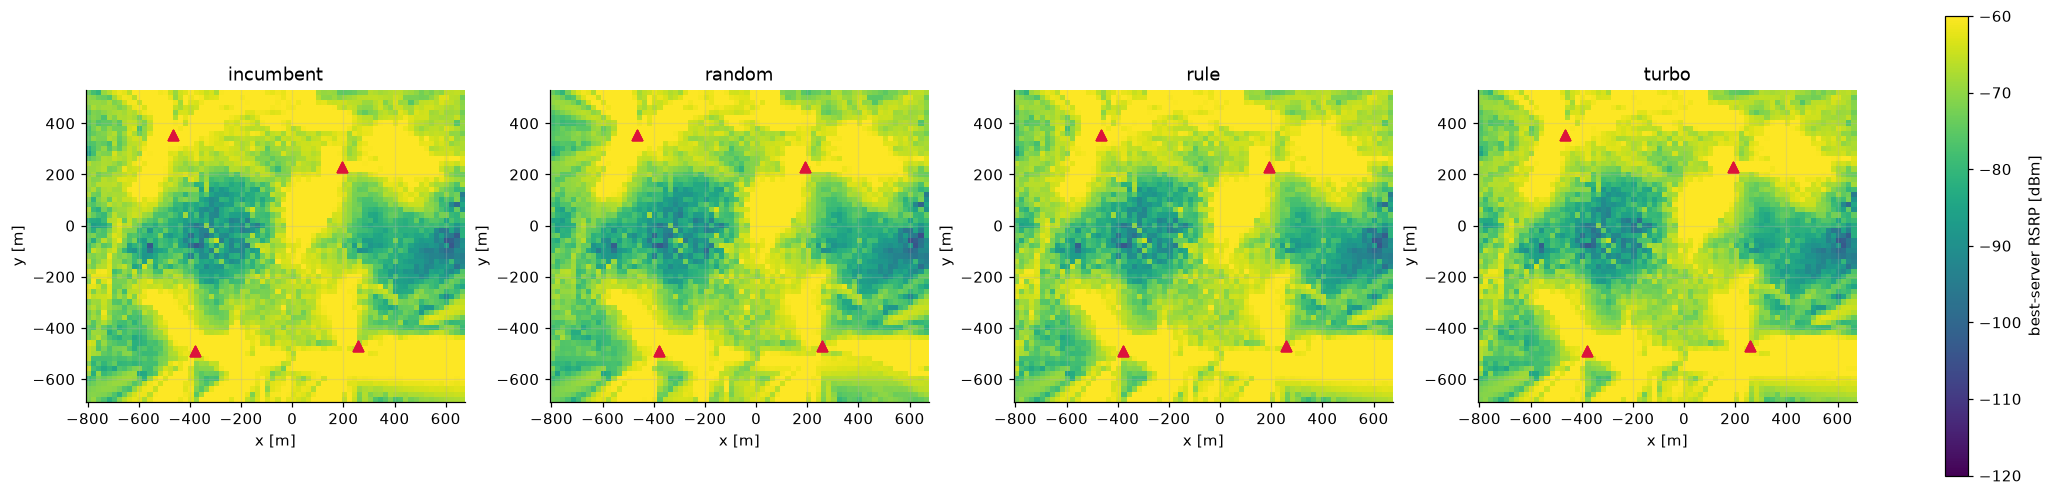

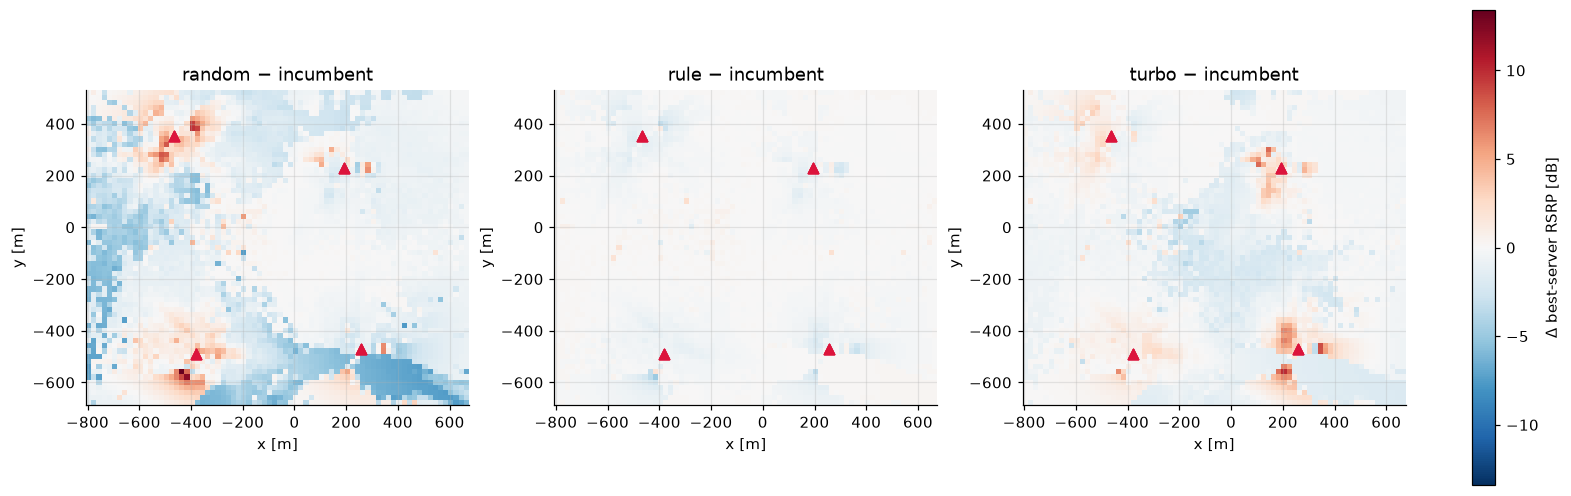

In [ ]:
best_rsrp = {name: max_rsrp(values) for name, values in rsrp.items()}
figure = plots.map_row(
    best_rsrp,
    baseline,
    label="best-server RSRP [dBm]",
    vmin=maps.RSRP_LIMITS[0],
    vmax=maps.RSRP_LIMITS[1],
    cells=cells,
)
save_fig(figure, "rsrp_maps")
plt.show()

figure = plots.map_row(
    {f"{method} − incumbent": best_rsrp[method] - best_rsrp["incumbent"] for method in methods},
    baseline,
    label="Δ best-server RSRP [dB]",
    symmetric=True,
    cells=cells,
)
save_fig(figure, "rsrp_delta_maps")
plt.show()

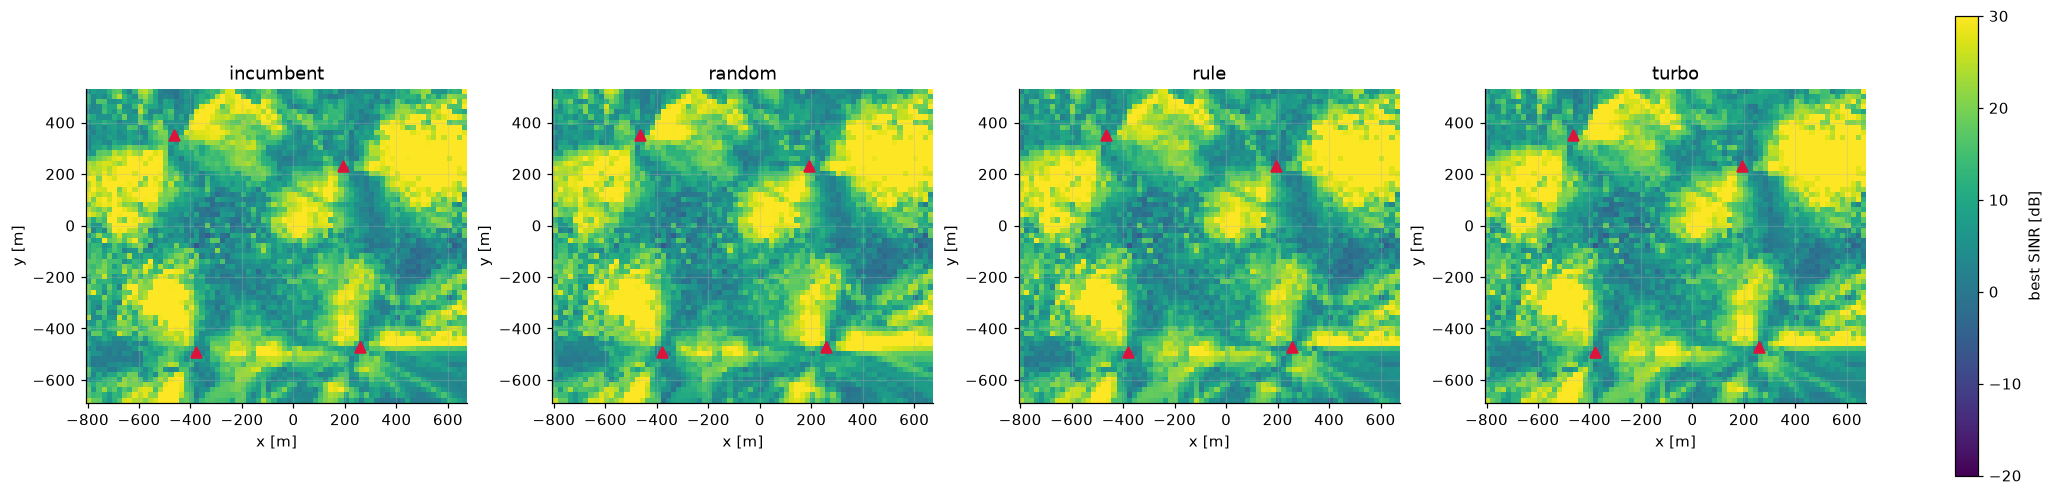

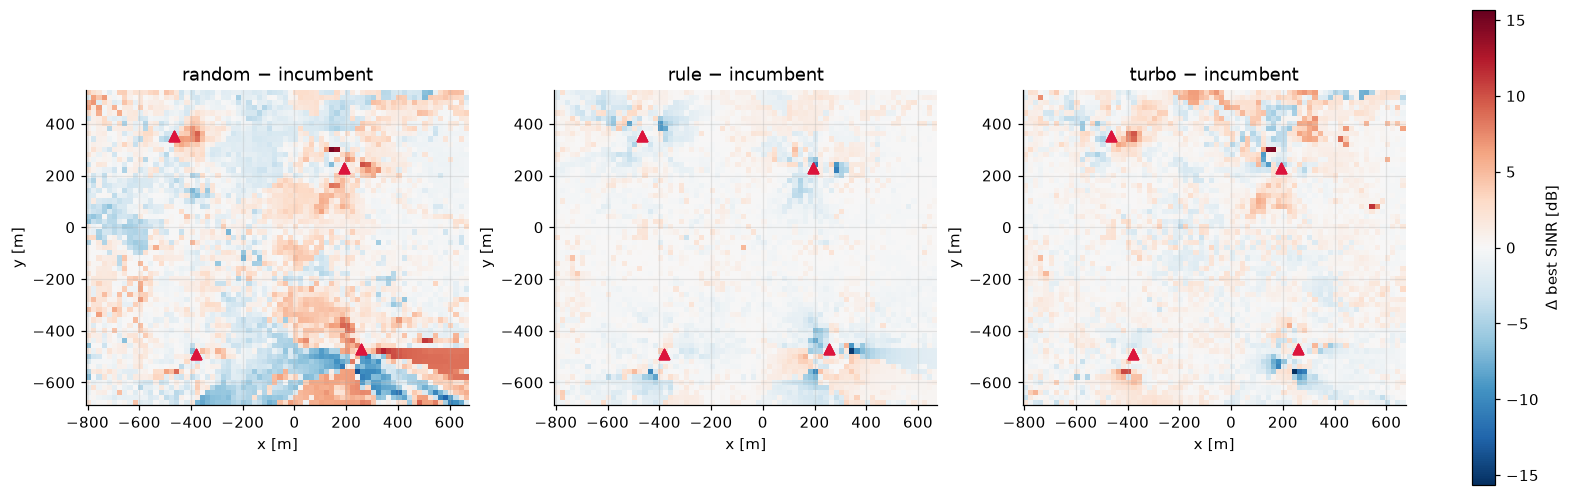

In [ ]:
best_sinr = {name: maps.best_sinr(values) for name, values in sinr.items()}
figure = plots.map_row(
    best_sinr,
    baseline,
    label="best SINR [dB]",
    vmin=maps.SINR_LIMITS[0],
    vmax=maps.SINR_LIMITS[1],
    cells=cells,
)
save_fig(figure, "sinr_maps")
plt.show()

figure = plots.map_row(
    {f"{method} − incumbent": best_sinr[method] - best_sinr["incumbent"] for method in methods},
    baseline,
    label="Δ best SINR [dB]",
    symmetric=True,
    cells=cells,
)
save_fig(figure, "sinr_delta_maps")
plt.show()

## 5. Coverage crossings

The winner's threshold crossings first: a tile gaining 3 dB while staying a hole
has changed nothing a KPI can see, so this map shows only tiles that changed
class. Then every configuration's coverage classes by area (the KPI) and by
demand (what users would notice), and the CDFs behind both.

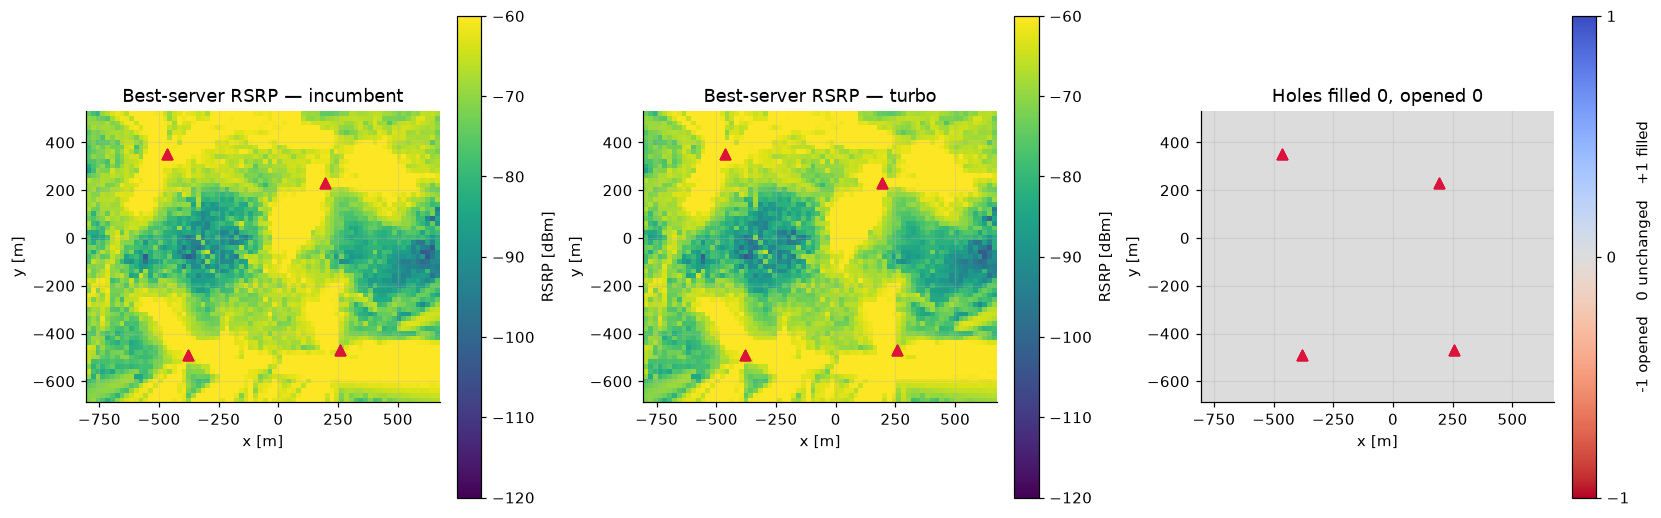

,coverage,incumbent_tile,incumbent_demand,random_tile,random_demand,rule_tile,rule_demand,turbo_tile,turbo_demand
0,hole,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
1,weak,0.023261,0.034689,0.025255,0.03416,0.023039,0.034689,0.025698,0.037387
2,good,0.976739,0.965311,0.974745,0.96584,0.976961,0.965311,0.974302,0.962613


In [ ]:
figure = plots.coverage_maps(
    best_rsrp["incumbent"],
    best_rsrp[winner.method],
    baseline,
    cfg,
    cells=cells,
    label=winner.method,
)
save_fig(figure, "coverage_before_after")
plt.show()

coverage = {name: maps.coverage_table(rsrp[name], counts, cfg) for name in archives}
side_by_side = compare.coverage_comparison(coverage)
save_table(side_by_side, "coverage_by_area_and_demand")
side_by_side

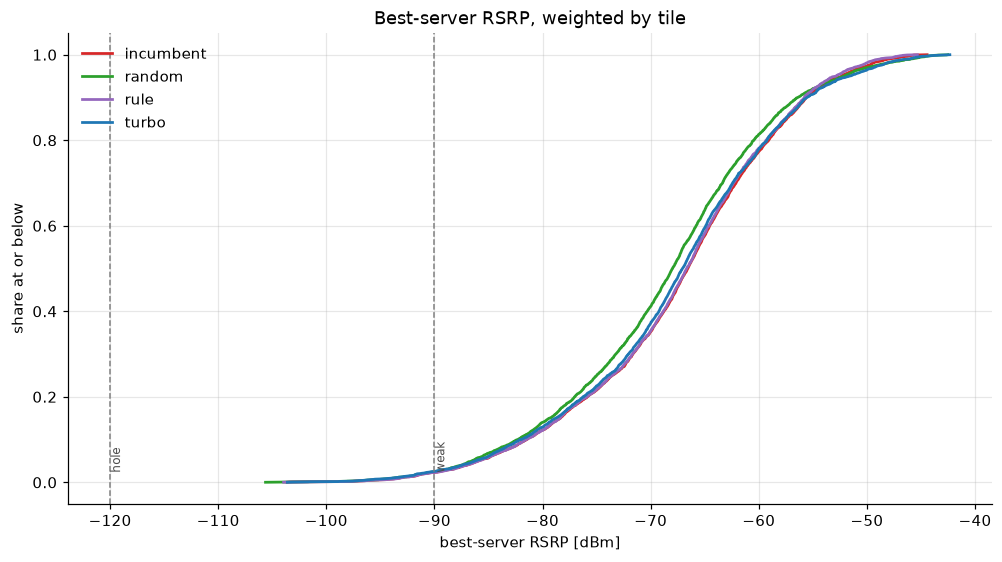

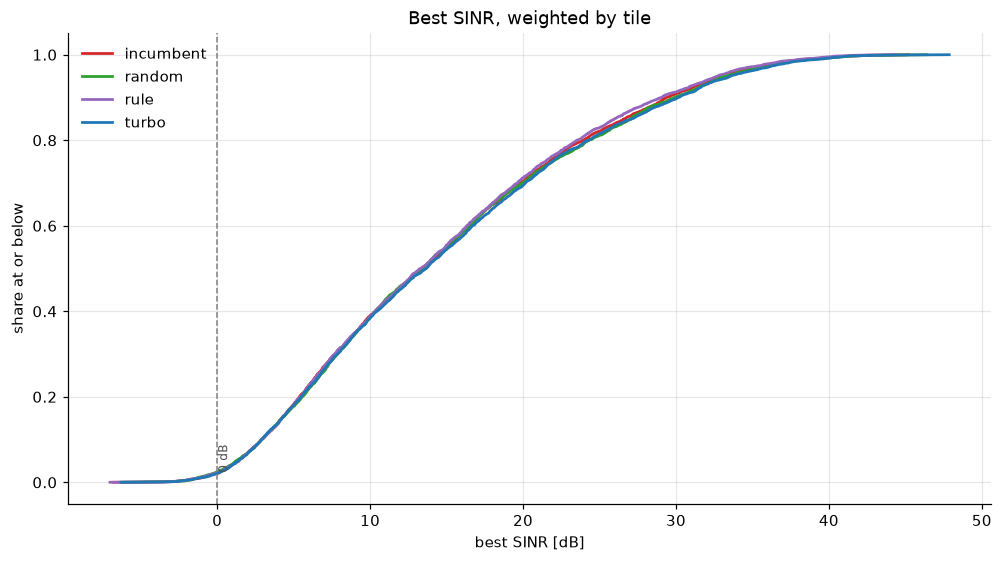

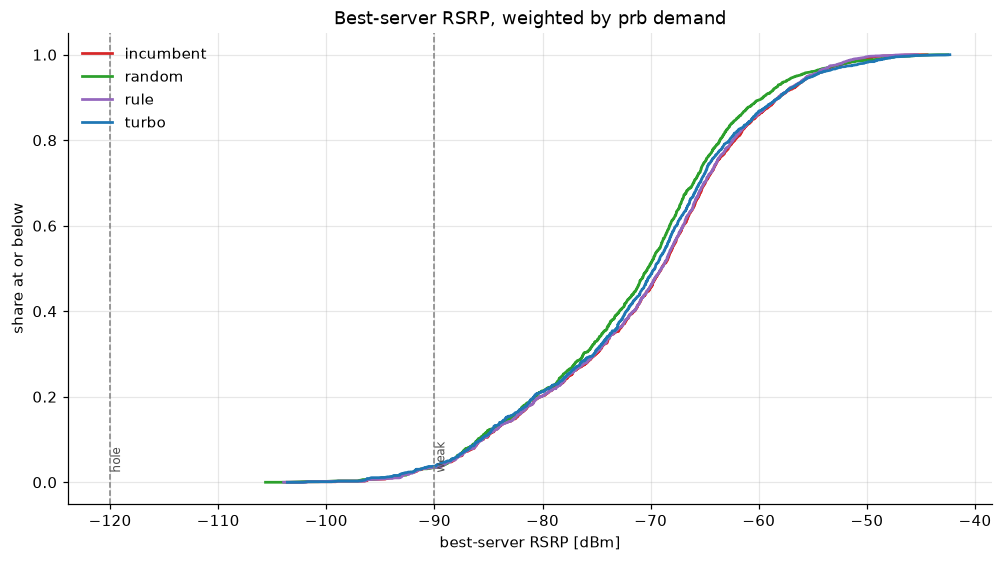

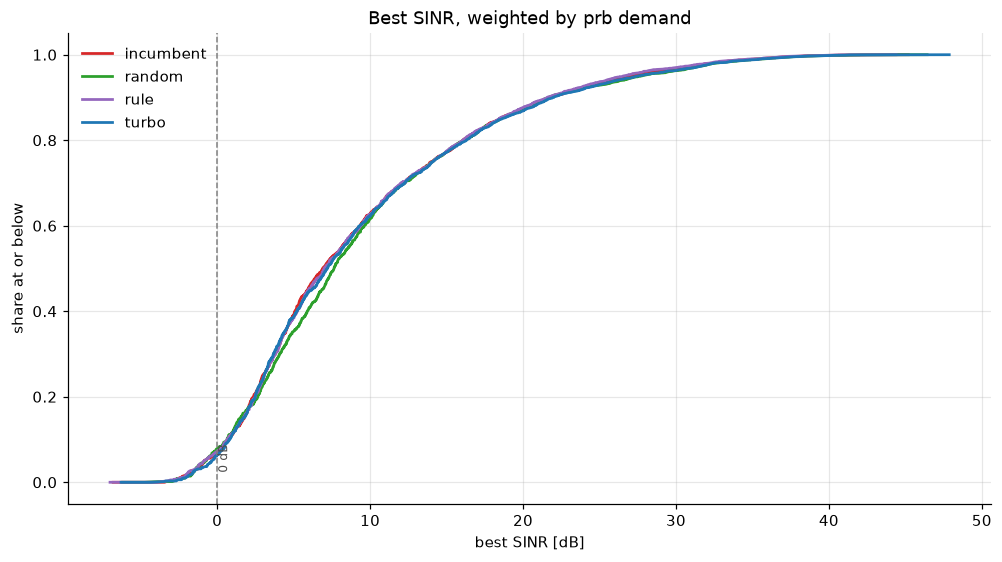

In [ ]:
for weighting, weights in (("tile", None), ("prb_demand", counts)):
    figure = plots.cdf_comparison(
        best_rsrp,
        xlabel="best-server RSRP [dBm]",
        title=f"Best-server RSRP, weighted by {weighting.replace('_', ' ')}",
        thresholds={"hole": float(cfg.kpi.hole_dbm), "weak": float(cfg.kpi.weak_dbm)},
        weights=weights,
    )
    save_fig(figure, f"rsrp_cdf_{weighting}")
    plt.show()

    figure = plots.cdf_comparison(
        best_sinr,
        xlabel="best SINR [dB]",
        title=f"Best SINR, weighted by {weighting.replace('_', ' ')}",
        thresholds={"0 dB": 0.0},
        weights=weights,
    )
    save_fig(figure, f"sinr_cdf_{weighting}")
    plt.show()

## 6. Overlap and interference

Co-band neighbours within `kpi.overlap_margin_db` of the serving cell, summed over
bands: the count behind the overlap rate. More neighbours in range is more
interference and more handover churn. On the difference maps blue is fewer
neighbours, which is the improvement.

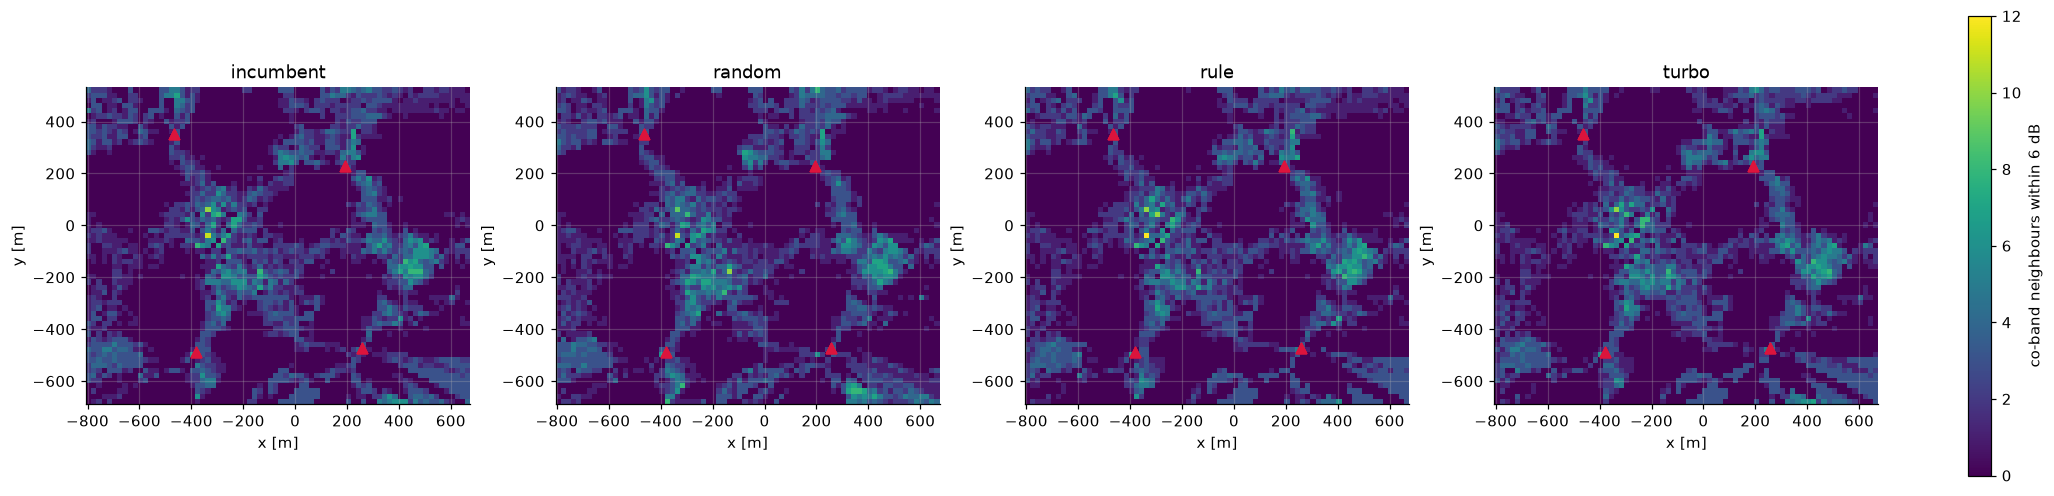

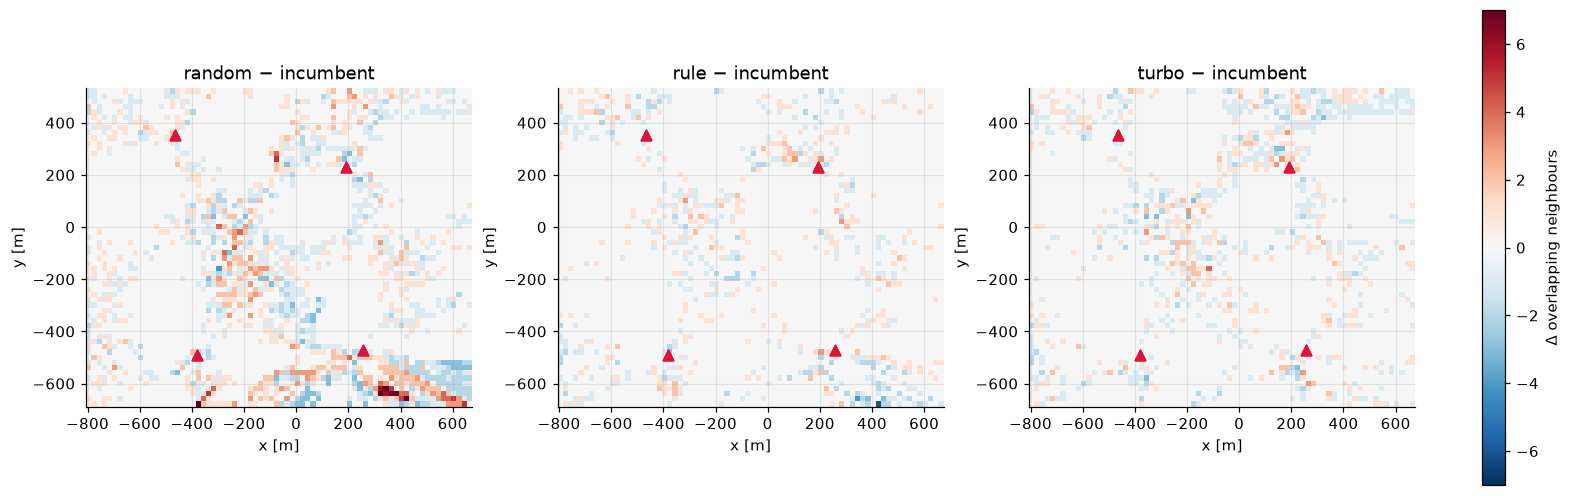

In [ ]:
overlap = {name: overlap_neighbors(values, cfg).astype(float) for name, values in rsrp.items()}
figure = plots.map_row(
    overlap,
    baseline,
    label=f"co-band neighbours within {float(cfg.kpi.overlap_margin_db):g} dB",
    vmin=0.0,
    cells=cells,
)
save_fig(figure, "overlap_maps")
plt.show()

figure = plots.map_row(
    {f"{method} − incumbent": overlap[method] - overlap["incumbent"] for method in methods},
    baseline,
    label="Δ overlapping neighbours",
    symmetric=True,
    cells=cells,
)
save_fig(figure, "overlap_delta_maps")
plt.show()

## 7. Capacity and demand

Capacity settings in `kpi.capacity` are placeholders pending the maintainer's
numbers, so read absolute PRB counts as relative. The direction of change
between configurations is the evidence.

### UE service

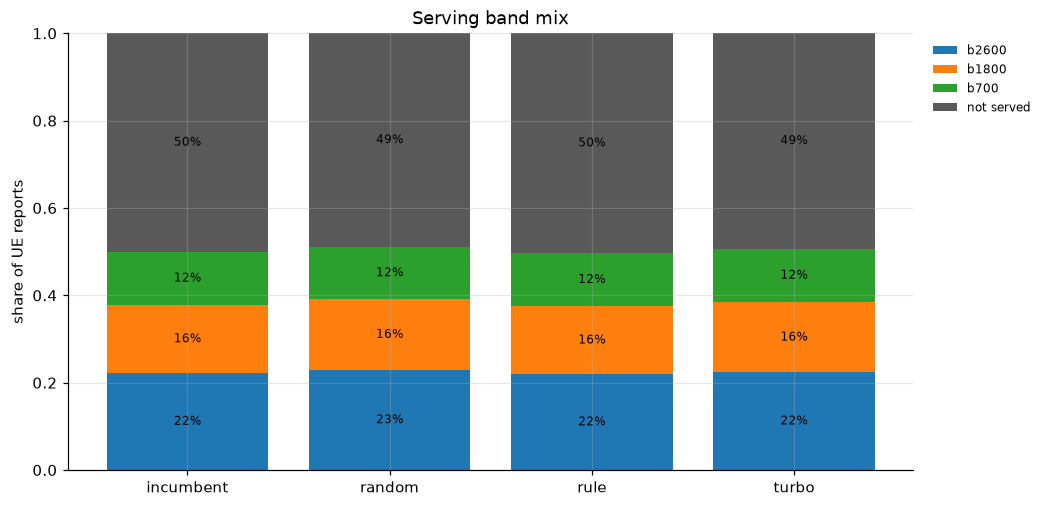

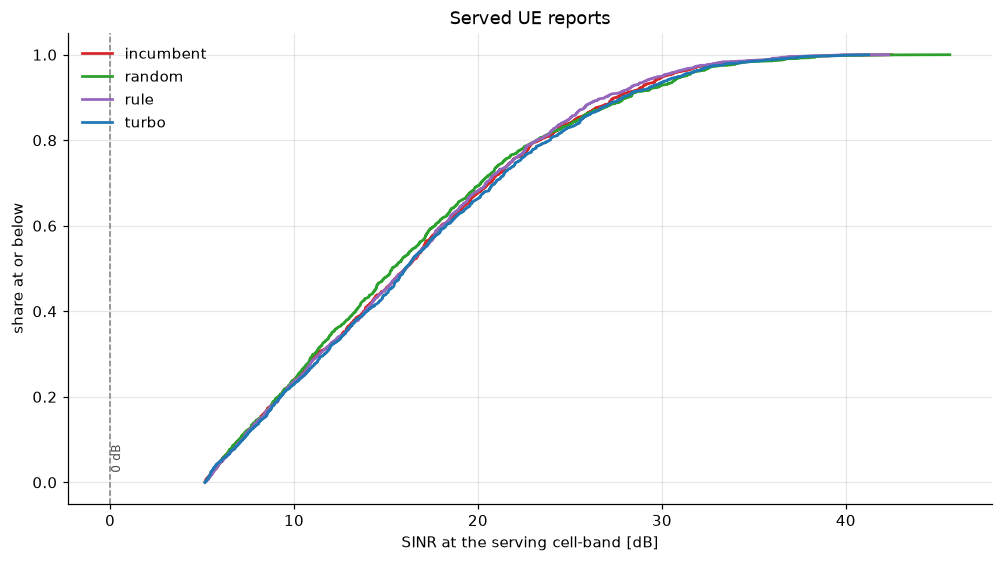

,configuration,reports,not_served_share,sinr_p10_db,sinr_median_db,prb_per_served_ue_median,share_b2600,share_b1800,share_b700
0,incumbent,9939.0,0.500352,7.057471,16.065424,41.366135,0.221753,0.155951,0.121944
1,random,9939.0,0.488782,7.008605,15.338029,43.260971,0.228796,0.161888,0.120535
2,rule,9939.0,0.503572,7.170409,16.045351,41.416300,0.219137,0.155448,0.121843
3,turbo,9939.0,0.492907,7.220192,16.057707,41.385407,0.223363,0.160278,0.123453


In [ ]:
summaries = {name: compare.service_summary(frame, band_labels) for name, frame in served.items()}
service = pd.DataFrame(summaries).T.rename_axis("configuration").reset_index()
save_table(service, "ue_service_summary")

figure = plots.band_share_bars(summaries, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

figure = plots.cdf_comparison(
    {name: frame.loc[frame["band"] >= 0, "sinr_db"].to_numpy() for name, frame in served.items()},
    xlabel="SINR at the serving cell-band [dB]",
    title="Served UE reports",
    thresholds={"0 dB": 0.0},
)
save_fig(figure, "served_sinr_cdf")
plt.show()
service

### PRB demand

PRBs required per tile in its busiest interval. Demand moves with the map:
better SINR means fewer PRBs per UE. Blank tiles hold no report. On the
difference maps blue is less demand.

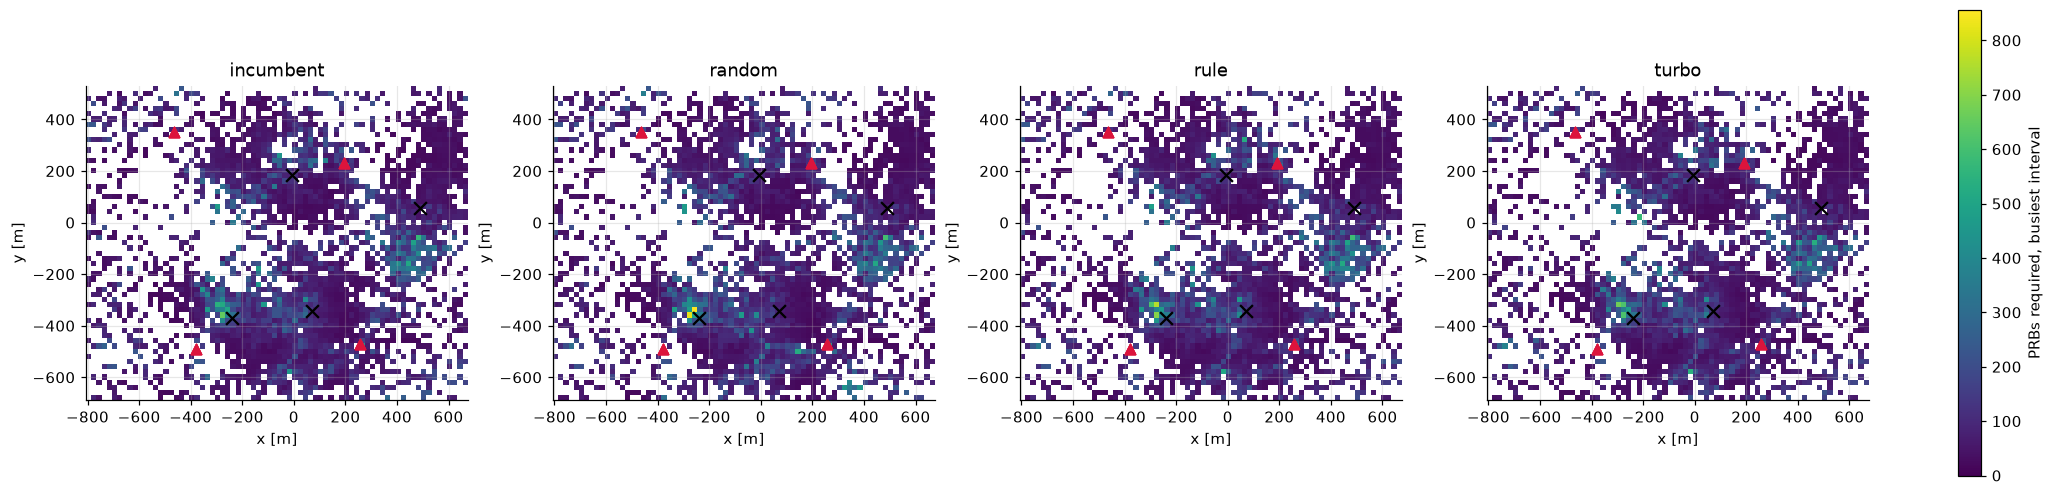

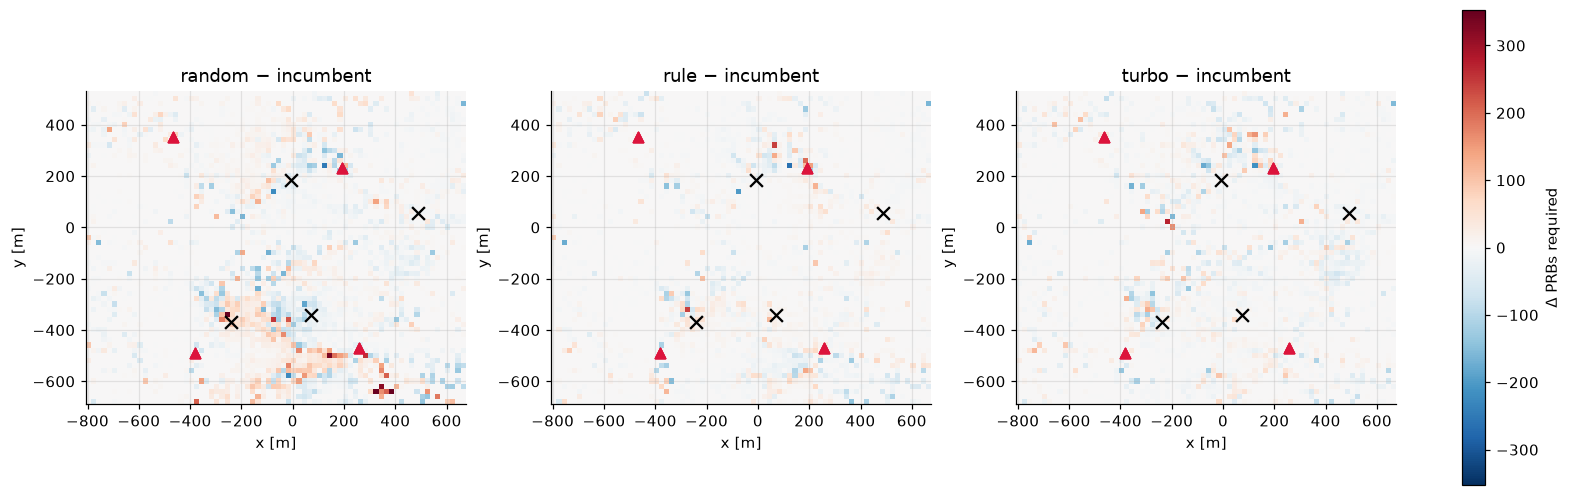

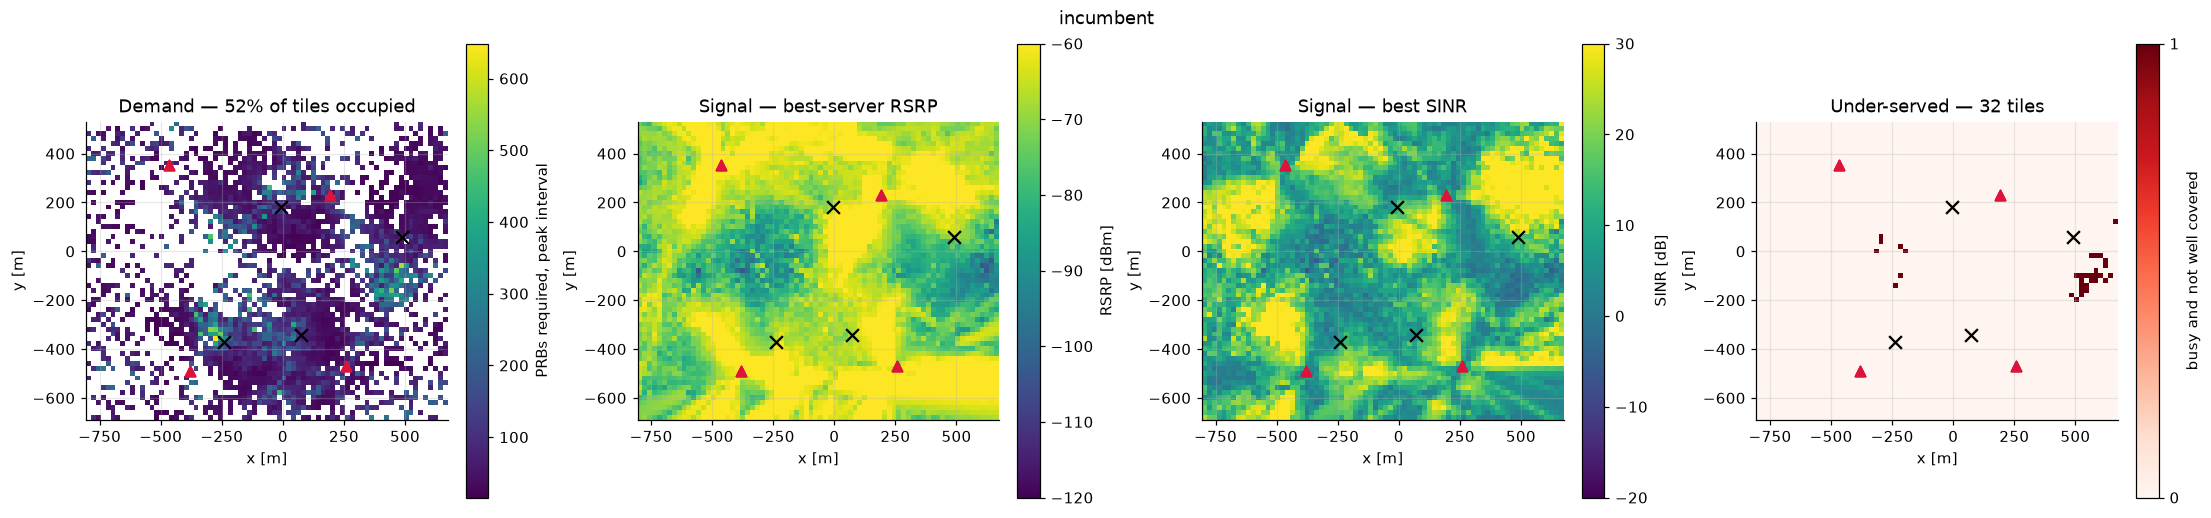

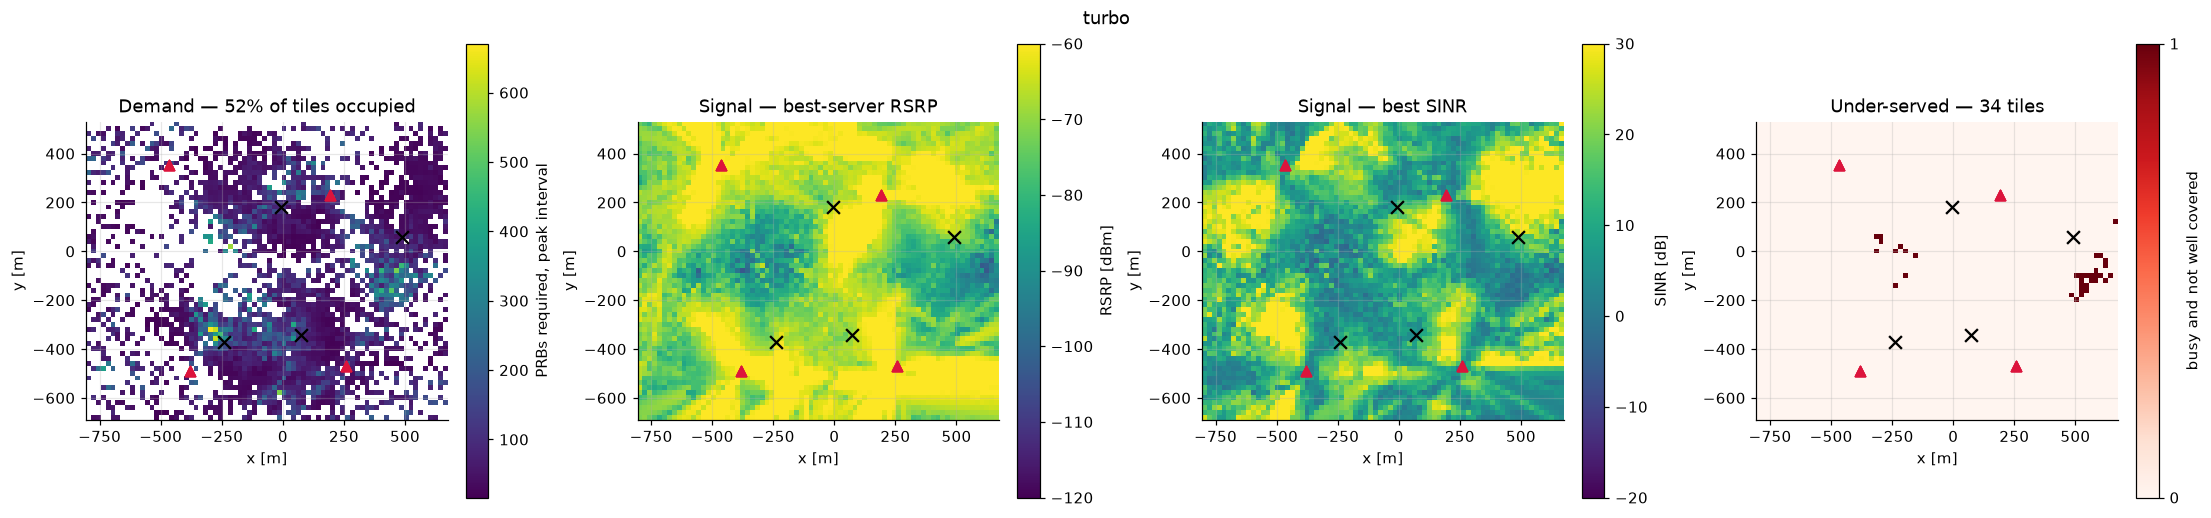

In [ ]:
figure = plots.map_row(
    {name: np.where(values > 0, values, np.nan) for name, values in demand.items()},
    baseline,
    label="PRBs required, busiest interval",
    cells=cells,
    hotspots=hotspots,
)
save_fig(figure, "demand_maps")
plt.show()

figure = plots.map_row(
    {f"{method} − incumbent": demand[method] - demand["incumbent"] for method in methods},
    baseline,
    label="Δ PRBs required",
    symmetric=True,
    cells=cells,
    hotspots=hotspots,
)
save_fig(figure, "demand_delta_maps")
plt.show()

for name in ("incumbent", winner.method):
    figure = plots.demand_signal_maps(
        rsrp[name], sinr[name], demand[name], baseline, cfg, cells=cells, hotspots=hotspots
    )
    figure.suptitle(name)
    save_fig(figure, f"demand_vs_signal_{name}")
    plt.show()

### Cell-band load

Peak PRB utilisation per cell-band over the busiest interval. A cell-band at
100% turned away UEs that preferred it; tilting it wider pulls in more traffic,
tilting it down sheds traffic to neighbours.

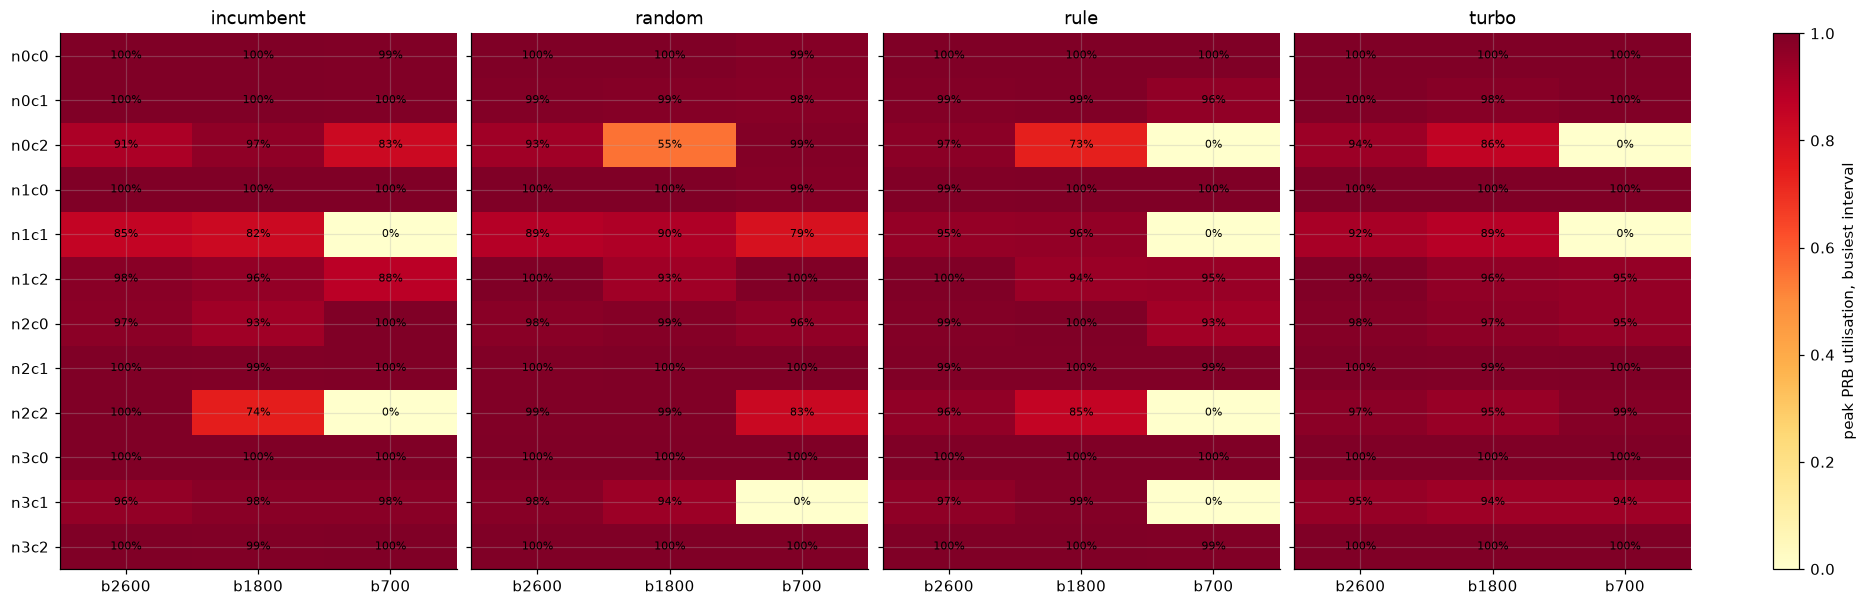

In [ ]:
load = {
    name: compare.cell_band_load(frame, band_labels, tx_names, spec.max_prb)
    for name, frame in served.items()
}
figure = plots.utilisation_heatmaps(load)
save_fig(figure, "cell_band_utilisation")
plt.show()

### Serving band footprint

Which band serves each tile under the priority rule, before PRB limits. A tilt
change that shrinks a preferred band's footprint shows up here as the next band
taking over.

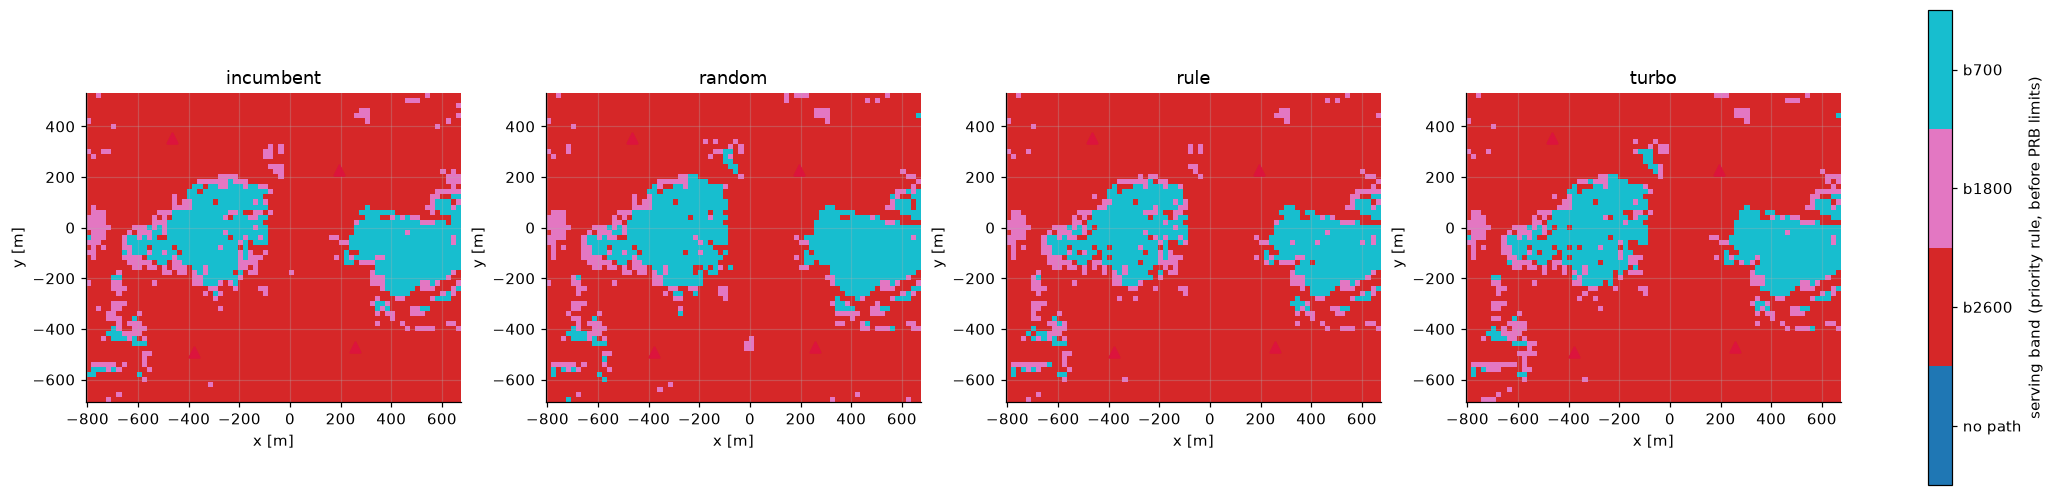

In [ ]:
n_band = len(band_labels)
footprint = {
    name: maps.serving_band(values, spec.band_rank, spec.rsrp_threshold_dbm).astype(float)
    for name, values in rsrp.items()
}
figure = plots.map_row(
    footprint,
    baseline,
    label="serving band (priority rule, before PRB limits)",
    vmin=-1.5,
    vmax=n_band - 0.5,
    cmap=plt.get_cmap("tab10", n_band + 1),
    cells=cells,
    ticks=list(range(-1, n_band)),
    ticklabels=["no path", *band_labels],
)
save_fig(figure, "serving_band_footprint")
plt.show()

## 8. Per-cell impact of the recommended configuration

One row per cell-band of the winner: its tilt change and what it did to that
cell-band's served UE reports, peak PRB utilisation and median SINR of the UEs it
served. Sorted by the size of the traffic shift, so the cells to watch after
rollout come first.

In [ ]:
columns = ["cell", "band", "served_reports", "peak_utilisation", "median_sinr_db"]
impact = (
    winner.best_tilt[["cell", "band", "current_tilt_deg", "optimized_tilt_deg", "delta_tilt_deg"]]
    .astype({"cell": str, "band": str})
    .merge(load["incumbent"][columns], on=["cell", "band"])
    .merge(load[winner.method][columns], on=["cell", "band"], suffixes=("_before", "_after"))
    .merge(cells[["cell", "node", "azimuth_deg"]].astype({"cell": str}), on="cell")
)
impact["served_reports_delta"] = impact["served_reports_after"] - impact["served_reports_before"]
impact["peak_utilisation_delta"] = (
    impact["peak_utilisation_after"] - impact["peak_utilisation_before"]
)
impact["median_sinr_delta_db"] = impact["median_sinr_db_after"] - impact["median_sinr_db_before"]
impact = impact[
    [
        "node",
        "cell",
        "azimuth_deg",
        "band",
        "current_tilt_deg",
        "optimized_tilt_deg",
        "delta_tilt_deg",
        "served_reports_before",
        "served_reports_after",
        "served_reports_delta",
        "peak_utilisation_before",
        "peak_utilisation_after",
        "peak_utilisation_delta",
        "median_sinr_db_before",
        "median_sinr_db_after",
        "median_sinr_delta_db",
    ]
].sort_values("served_reports_delta", key=np.abs, ascending=False, ignore_index=True)

save_table(impact, f"cell_impact_{winner.method}")
print(winner.label)
impact.round(3)

turbo/2026-09-13_05-56-15


,node,cell,azimuth_deg,band,current_tilt_deg,optimized_tilt_deg,delta_tilt_deg,served_reports_before,served_reports_after,served_reports_delta,peak_utilisation_before,peak_utilisation_after,peak_utilisation_delta,median_sinr_db_before,median_sinr_db_after,median_sinr_delta_db
0,n0,n0c0,0.0,b1800,6.0,4.791,-1.209,352,375,23,1.000,0.998,-0.002,19.354,20.697,1.343
1,n3,n3c2,240.0,b2600,8.0,8.489,0.489,415,436,21,1.000,0.999,-0.001,23.889,24.602,0.712
2,n1,n1c0,0.0,b700,4.0,3.242,-0.758,121,141,20,1.000,0.997,-0.002,10.767,10.819,0.052
3,n1,n1c0,0.0,b1800,6.0,11.961,5.961,187,168,-19,0.999,0.999,-0.000,14.968,14.477,-0.491
4,n3,n3c1,120.0,b1800,6.0,13.201,7.201,12,30,18,0.977,0.935,-0.041,5.455,8.799,3.344
5,n3,n3c0,0.0,b1800,6.0,5.072,-0.928,265,279,14,0.997,0.999,0.002,15.698,17.354,1.657
6,n0,n0c1,120.0,b2600,8.0,1.578,-6.422,240,226,-14,0.999,0.996,-0.003,18.370,19.294,0.924
7,n2,n2c1,120.0,b1800,6.0,8.894,2.894,219,205,-14,0.994,0.993,-0.001,12.219,11.834,-0.385
8,n1,n1c2,240.0,b2600,8.0,3.649,-4.351,102,113,11,0.977,0.994,0.017,17.110,15.389,-1.721
9,n3,n3c0,0.0,b700,4.0,5.420,1.420,277,266,-11,0.999,0.999,-0.000,16.437,15.703,-0.734


## 9. How far the antennas moved

Reported, never optimized: a movement penalty is an explicit non-goal, so nothing
in the objective has seen these numbers.

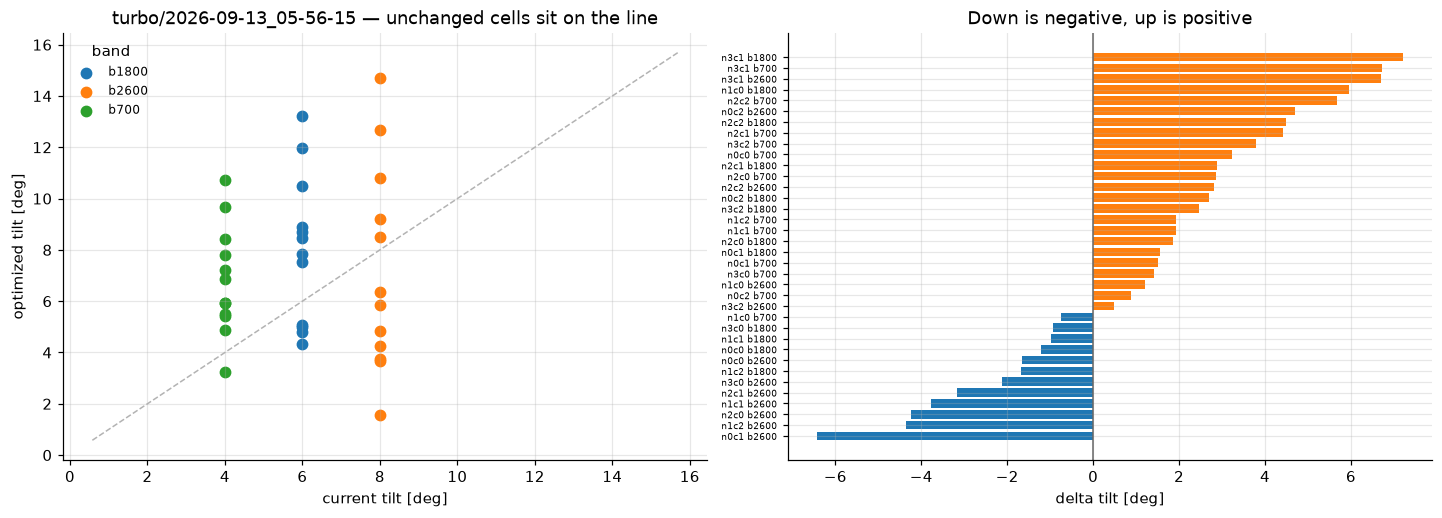

,band,n_cells,n_moved,mean_abs_delta_deg,max_abs_delta_deg,mean_delta_deg
0,b1800,12,12,2.826046,7.201430,2.024470
1,b2600,12,12,3.466552,6.688235,-0.820084
2,b700,12,12,2.924767,6.732410,2.798414


In [ ]:
movement = compare.tilt_movement(winner)
save_table(movement, f"tilt_movement_{winner.method}")
save_table(winner.best_tilt, f"best_tilt_{winner.method}")

figure = plots.tilt_movement_plot(winner)
save_fig(figure, "tilt_movement")
plt.show()
movement

## 10. Method diagnostics

Matched on evaluations, not on wall clock: the model in `turbo` costs time that
`random` does not spend, so both columns are shown. The convergence curves say
whether a budget was still paying off when it ran out.

In [ ]:
table = compare.method_table(runs, cfg)
save_table(table, "method_comparison")

trace = compare.convergence(runs)
save_table(trace, "convergence")
figure = plots.convergence_plot(trace)
save_fig(figure, "convergence")
plt.show()
table

## 11. What was written

In [ ]:
for directory in (Path("reports/figures/04_evaluation"), Path("reports/tables/04_evaluation")):
    written = sorted(directory.glob("*")) if directory.exists() else []
    print(f"{directory}: {len(written)} files")
    for path in written:
        print(f"  {path.name}")

reports\figures\05_evaluation: 26 files
  cell_band_utilisation.png
  convergence.png
  coverage_before_after.png
  coverage_cdf.png
  demand_delta_maps.png
  demand_maps.png
  demand_vs_signal.png
  demand_vs_signal_incumbent.png
  demand_vs_signal_turbo.png
  kpi_improvement_vs_tolerance.png
  overlap_delta_maps.png
  overlap_maps.png
  pareto_front.png
  rsrp_cdf_prb_demand.png
  rsrp_cdf_tile.png
  rsrp_delta_maps.png
  rsrp_maps.png
  served_sinr_cdf.png
  serving_band_footprint.png
  serving_band_mix.png
  sinr_cdf_prb_demand.png
  sinr_cdf_tile.png
  sinr_delta_maps.png
  sinr_maps.png
  tilt_movement.png
  verdict_per_kpi.png
reports\tables\05_evaluation: 10 files
  best_tilt_turbo.csv
  cell_impact_turbo.csv
  convergence.csv
  coverage_by_area_and_demand.csv
  delta_turbo.csv
  kpi_reproducibility.csv
  kpi_scoreboard.csv
  method_comparison.csv
  tilt_movement_turbo.csv
  ue_service_summary.csv


## 12. Conclusions

State what was decided and on what evidence, not just the winning row.

- **Configuration to deploy:** `<method / run id>`
- **What it gained:** `<which KPIs moved past tolerance, and by how much>`
- **What it cost:** `<KPIs that worsened, and the wall clock>`
- **How a user would see it:** `<the demand-weighted change, not the tile one>`
- **Confidence:** `<were the budgets large enough for this to mean anything?>`
- **Reproduced by:** commit `<hash>`, scenario `<scenario_id>`


## 13. Handoff checklist

- [ ] Every run compared passed `verify` - same scenario, same fidelity, same thresholds
- [ ] The incumbent row matches `data/interim/radio_map.npz`
- [ ] Deltas smaller than their tolerance are read as ties, not as wins
- [ ] The demand-weighted numbers are reported as diagnostics, not as KPIs
- [ ] Budgets were large enough to compare methods, or the notebook says they were not
- [ ] Figures and tables are in `reports/`
